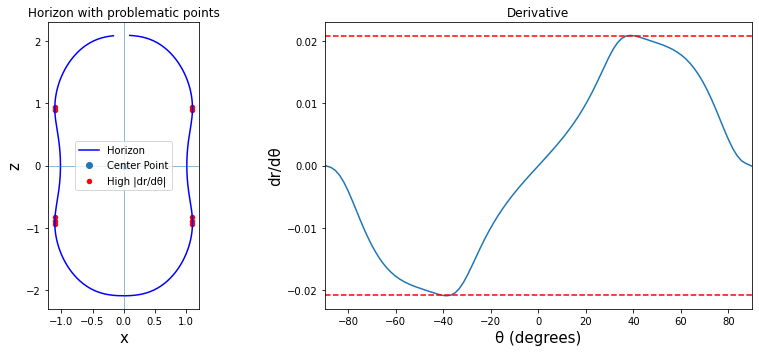

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load horizon
# =========================
horizon = np.loadtxt(
    "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.117_4.117/4.117_4.117/zaxis/hor.txt",
    skiprows=1
)

x = horizon[:,0]
z = horizon[:,2]

# =========================
# Build closed curve
# =========================
x_m = -x[1:-1]
z_m =  z[1:-1]

x_curve = np.concatenate([x, x_m[::-1]])
z_curve = np.concatenate([z, z_m[::-1]])

# =========================
# Choose center
# =========================
x_c = 0.0
z_c = 0.0

# =========================
# Compute r, theta
# =========================
dx = x_curve - x_c
dz = z_curve - z_c

r = np.sqrt(dx**2 + dz**2)
theta = np.arctan2(dz, dx)

# =========================
# Bin theta
# =========================
bins = np.linspace(-np.pi,np.pi, 800)
digitized = np.digitize(theta, bins)

theta_binned = []
r_binned = []
x_binned = []
z_binned = []

for i in range(1, len(bins)):
    mask = digitized == i
    if np.any(mask):
        # take point with max r (outer surface)
        idx = np.argmax(r[mask])
        theta_binned.append(theta[mask][idx])
        r_binned.append(r[mask][idx])
        x_binned.append(x_curve[mask][idx])
        z_binned.append(z_curve[mask][idx])

theta_binned = np.array(theta_binned)
r_binned = np.array(r_binned)
x_binned = np.array(x_binned)
z_binned = np.array(z_binned)

# =========================
# Sort
# =========================
idx = np.argsort(theta_binned)
theta_binned = theta_binned[idx]
r_binned = r_binned[idx]
x_binned = x_binned[idx]
z_binned = z_binned[idx]

# =========================
# Derivative
# =========================
theta_deg = np.degrees(theta_binned)
dr_dtheta = np.gradient(r_binned, theta_deg)

# =========================
# Find problematic points
# =========================
threshold = np.percentile(np.abs(dr_dtheta), 95)  # top 5%
bad = np.abs(dr_dtheta) > threshold

# =========================
# Plot
# =========================
plt.figure(figsize=(12,5))

# --- Horizon plot ---
plt.subplot(1,2,1)
plt.plot(x_curve, z_curve, 'b', label="Horizon")

# highlight problematic points
plt.scatter(x_binned[bad], z_binned[bad],
            color='red', s=20, label="High |dr/dθ|")

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.gca().set_aspect('equal')
plt.xlabel("x",fontsize=15)
plt.ylabel("z",fontsize=15)
plt.title("Horizon with problematic points")
plt.plot(0, 0, 'o',label="Center Point")

plt.legend()
  # 'o' creates a dot
# --- Derivative plot ---
plt.subplot(1,2,2)
plt.plot(theta_deg, dr_dtheta)
plt.axhline(threshold, color='r', linestyle='--')
plt.axhline(-threshold, color='r', linestyle='--')
plt.xlim(-90,90)
#plt.ylim(-0.6,0.6)
plt.xlabel("θ (degrees)",fontsize=15)
plt.ylabel("dr/dθ",fontsize=15)
plt.title("Derivative")
plt.savefig("peanutproblematic.pdf")
plt.tight_layout()
plt.show()

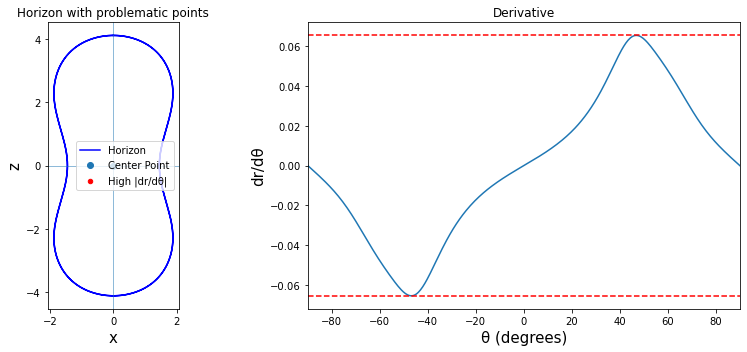

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load horizon
# =========================
horizon = np.loadtxt(
    "/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.113_hdwg.txt",
    skiprows=1
)

x = horizon[:,0]
z = horizon[:,1]

# =========================
# Build closed curve
# =========================
x_m = -x[1:-1]
z_m =  z[1:-1]

x_curve = np.concatenate([x, x_m[::-1]])
z_curve = np.concatenate([z, z_m[::-1]])

# =========================
# Choose center
# =========================
x_c = 0.0
z_c = 0.0

# =========================
# Compute r, theta
# =========================
dx = x_curve - x_c
dz = z_curve - z_c

r = np.sqrt(dx**2 + dz**2)
theta = np.arctan2(dz, dx)

# =========================
# Bin theta
# =========================
bins = np.linspace(-np.pi,np.pi, 800)
digitized = np.digitize(theta, bins)

theta_binned = []
r_binned = []
x_binned = []
z_binned = []

for i in range(1, len(bins)):
    mask = digitized == i
    if np.any(mask):
        # take point with max r (outer surface)
        idx = np.argmax(r[mask])
        theta_binned.append(theta[mask][idx])
        r_binned.append(r[mask][idx])
        x_binned.append(x_curve[mask][idx])
        z_binned.append(z_curve[mask][idx])

theta_binned = np.array(theta_binned)
r_binned = np.array(r_binned)
x_binned = np.array(x_binned)
z_binned = np.array(z_binned)

# =========================
# Sort
# =========================
idx = np.argsort(theta_binned)
theta_binned = theta_binned[idx]
r_binned = r_binned[idx]
x_binned = x_binned[idx]
z_binned = z_binned[idx]

# =========================
# Derivative
# =========================
theta_deg = np.degrees(theta_binned)
dr_dtheta = np.gradient(r_binned, theta_deg)

# =========================
# Find problematic points
# =========================
threshold = np.percentile(np.abs(dr_dtheta), 100)  # top 5%
bad = np.abs(dr_dtheta) > threshold

# =========================
# Plot
# =========================
plt.figure(figsize=(12,5))

# --- Horizon plot ---
plt.subplot(1,2,1)
plt.plot(x_curve, z_curve, 'b', label="Horizon")

# highlight problematic points
plt.scatter(x_binned[bad], z_binned[bad],
            color='red', s=20, label="High |dr/dθ|")

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.gca().set_aspect('equal')
plt.xlabel("x",fontsize=15)
plt.ylabel("z",fontsize=15)
plt.title("Horizon with problematic points")
plt.plot(0, 0, 'o',label="Center Point")

plt.legend()
  # 'o' creates a dot
# --- Derivative plot ---
plt.subplot(1,2,2)
plt.plot(theta_deg, dr_dtheta)
plt.axhline(threshold, color='r', linestyle='--')
plt.axhline(-threshold, color='r', linestyle='--')
plt.xlim(-90,90)
#plt.ylim(-0.6,0.6)
plt.xlabel("θ (degrees)",fontsize=15)
plt.ylabel("dr/dθ",fontsize=15)
plt.title("Derivative")
plt.savefig("peanutnonproblematic.pdf")
plt.tight_layout()
plt.show()